![Illustration of silhouetted heads](mentalhealth.jpg)

Does going to university in a different country affect your mental health? A Japanese international university surveyed its students in 2018 and published a study the following year that was approved by several ethical and regulatory boards.

The study found that international students have a higher risk of mental health difficulties than the general population, and that social connectedness (belonging to a social group) and acculturative stress (stress associated with joining a new culture) are predictive of depression.


Explore the `students` data using PostgreSQL to find out if you would come to a similar conclusion for international students and see if the length of stay is a contributing factor.

Here is a data description of the columns you may find helpful.

| Field Name    | Description                                      |
| ------------- | ------------------------------------------------ |
| `inter_dom`     | Types of students (international or domestic)   |
| `japanese_cate` | Japanese language proficiency                    |
| `english_cate`  | English language proficiency                     |
| `academic`      | Current academic level (undergraduate or graduate) |
| `age`           | Current age of student                           |
| `stay`          | Current length of stay in years                  |
| `todep`         | Total score of depression (PHQ-9 test)           |
| `tosc`          | Total score of social connectedness (SCS test)   |
| `toas`          | Total score of acculturative stress (ASISS test) |

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("students.csv")
df.head()

,inter_dom,region,gender,academic,age,age_cate,stay,stay_cate,japanese,japanese_cate,...,friends_bi,parents_bi,relative_bi,professional_bi,phone_bi,doctor_bi,religion_bi,alone_bi,others_bi,internet_bi
0,Inter,SEA,Male,Grad,24.0,4.0,5.0,Long,3.0,Average,...,Yes,Yes,No,No,No,No,No,No,No,No
1,Inter,SEA,Male,Grad,28.0,5.0,1.0,Short,4.0,High,...,Yes,Yes,No,No,No,No,No,No,No,No
2,Inter,SEA,Male,Grad,25.0,4.0,6.0,Long,4.0,High,...,No,No,No,No,No,No,No,No,No,No
3,Inter,EA,Female,Grad,29.0,5.0,1.0,Short,2.0,Low,...,Yes,Yes,Yes,Yes,No,No,No,No,No,No
4,Inter,EA,Female,Grad,28.0,5.0,1.0,Short,1.0,Low,...,Yes,Yes,No,Yes,No,Yes,Yes,No,No,No


In [3]:
# Cut the df down to just inter_dom, japanese_cate, english_cate, academic, age, stay, todep, tosc, toas
df = df[["inter_dom", "japanese_cate", "english_cate", "academic", "age", "stay", "todep", "tosc", "toas"]]
df.head()

,inter_dom,japanese_cate,english_cate,academic,age,stay,todep,tosc,toas
0,Inter,Average,High,Grad,24.0,5.0,0.0,34.0,91.0
1,Inter,High,High,Grad,28.0,1.0,2.0,48.0,39.0
2,Inter,High,High,Grad,25.0,6.0,2.0,41.0,51.0
3,Inter,Low,Average,Grad,29.0,1.0,3.0,37.0,75.0
4,Inter,Low,Average,Grad,28.0,1.0,3.0,37.0,82.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286 entries, 0 to 285
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   inter_dom      268 non-null    object 
 1   japanese_cate  268 non-null    object 
 2   english_cate   268 non-null    object 
 3   academic       268 non-null    object 
 4   age            268 non-null    float64
 5   stay           268 non-null    float64
 6   todep          268 non-null    float64
 7   tosc           268 non-null    float64
 8   toas           268 non-null    float64
dtypes: float64(5), object(4)
memory usage: 20.2+ KB


In [5]:
df['inter_dom'].value_counts()

inter_dom
Inter    201
Dom       67
Name: count, dtype: int64

In [6]:
df["inter_dom"] = df["inter_dom"].astype("category")

In [7]:
df['japanese_cate'].value_counts()

japanese_cate
Low        92
Average    89
High       87
Name: count, dtype: int64

In [8]:
cat_type = pd.CategoricalDtype(
    categories=["Low", "Average", "High"],
    ordered=True
)

df["japanese_cate"] = df["japanese_cate"].astype(cat_type)

In [9]:
df["japanese_cate"].dtype

CategoricalDtype(categories=['Low', 'Average', 'High'], ordered=True, categories_dtype=object)

In [10]:
df["english_cate"].value_counts()

english_cate
High       166
Average     80
Low         22
Name: count, dtype: int64

In [11]:
df["english_cate"] = df["english_cate"].astype(cat_type)

In [12]:
df["academic"].value_counts()

academic
Under    247
Grad      21
Name: count, dtype: int64

In [13]:
df["academic"].astype("category")

0      Grad
1      Grad
2      Grad
3      Grad
4      Grad
       ... 
281     NaN
282     NaN
283     NaN
284     NaN
285     NaN
Name: academic, Length: 286, dtype: category
Categories (2, object): ['Grad', 'Under']

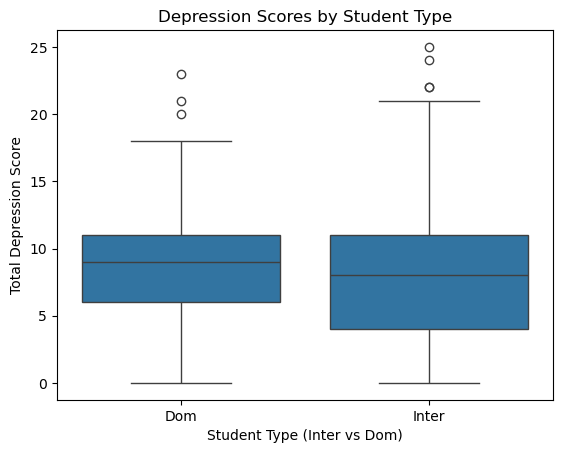

In [17]:
sns.boxplot(data=df, x="inter_dom", y="todep")
plt.xlabel("Student Type (Inter vs Dom)")
plt.ylabel("Total Depression Score")
plt.title("Depression Scores by Student Type")
plt.show()          